To run this, press "*Runtime*" and press "*Run all*" on a **free** Tesla T4 Google Colab instance!
<div class="align-center">
<a href="https://unsloth.ai/"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
<a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord button.png" width="145"></a>
<a href="https://docs.unsloth.ai/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a></a> Join Discord if you need help + ⭐ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐
</div>

To install Unsloth your local device, follow [our guide](https://docs.unsloth.ai/get-started/install-and-update). This notebook is licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme).

You will learn how to do [data prep](#Data), how to [train](#Train), how to [run the model](#Inference), & [how to save it](#Save)


### About Unsloth


Unsloth provides fast inference for vision-language models with vLLM integration.

Visit [Unsloth docs](https://docs.unsloth.ai/) for more information.


### Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.57.0
!pip install --no-deps trl==0.22.2

In [2]:
from unsloth import FastVisionModel
import torch
max_seq_length = 16384 # Must be this long for VLMs
lora_rank = 16 # Larger rank = smarter, but slower

model, tokenizer = FastVisionModel.from_pretrained(
    model_name = "unsloth/Qwen3-VL-8B-Thinking-unsloth-bnb-4bit",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # False for LoRA 16bit
    fast_inference = False, # Enable vLLM fast inference
    gpu_memory_utilization = 0.8, # Reduce if out of memory

)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2025.11.6: Fast Qwen3_Vl patching. Transformers: 4.57.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.91G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.46G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

### Upload Test Data

**Instructions:**
1. In Colab, click the 📁 folder icon (left sidebar)
2. Upload these files:
   - `Test.csv` (CSV file with column: Image_name)
   - `Image.zip` (ZIP file containing all test images)
3. Wait for upload to complete
4. Run the cells below in order

In [ ]:
# Extract the uploaded ZIP file
import zipfile
import os

print("🔍 Looking for Image.zip...\n")

# Find Image.zip file
zip_files = [f for f in os.listdir('.') if f == 'Image.zip' or f.endswith('.zip')]

if zip_files:
    zip_file = zip_files[0]
    print(f"✅ Found: {zip_file}")
    print("📦 Extracting...\n")

    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('.')

    print("✅ Extraction complete!")

    # Show extracted folders
    folders = [f for f in os.listdir('.') if os.path.isdir(f) and f not in ['sample_data', '.config', '__pycache__']]
    if folders:
        print(f"\n📁 Extracted folders:")
        for folder in folders:
            try:
                jpg_count = len([f for f in os.listdir(folder) if f.endswith('.jpg')])
                if jpg_count > 0:
                    print(f"   - {folder}/ ({jpg_count} images)")
            except:
                pass

    print("\n" + "="*60)
    print("✅ Ready! Continue to next cell")
    print("="*60)
else:
    print("❌ No ZIP file found!")
    print("\n⚠️ Please upload a ZIP file containing your test images")
    print("Then re-run this cell")

🔍 Looking for Image.zip...

✅ Found: Image.zip
📦 Extracting...

✅ Extraction complete!

📁 Extracted folders:
   - Image/ (330 images)

✅ Ready! Continue to next cell


### Verify Data

In [ ]:
# Verify uploaded data
import pandas as pd

print("🔍 Checking uploaded files...\n")

# Check for Test CSV
if os.path.exists("Test.csv"):
    print("✅ Test.csv found")
    test_df = pd.read_csv("Test.csv")
    print(f"   📊 Test set has {len(test_df)} images to classify")
    print(f"   📋 Columns: {list(test_df.columns)}")
    print(f"\n   First 5 entries:")
    print(test_df.head())

    # Find the image folder
    image_folder = None
    for item in os.listdir('.'):
        if os.path.isdir(item) and item not in ['sample_data', '.config']:
            try:
                files_in_folder = os.listdir(item)
                jpg_files = [f for f in files_in_folder if f.endswith('.jpg')]
                if len(jpg_files) > 0:
                    image_folder = item
                    print(f"\n✅ Found image folder: '{image_folder}'")
                    print(f"   📊 Contains {len(jpg_files)} .jpg images")
                    break
            except:
                continue

    if image_folder is None:
        print("\n❌ No image folder found!")
        print("Please run the extraction cell above first")
    else:
        # Save folder path for later use
        with open('image_folder_path.txt', 'w') as f:
            f.write(image_folder)

        # Check if all test images exist
        image_files = [f for f in os.listdir(image_folder) if f.endswith('.jpg')]
        missing_images = []
        for img_name in test_df['Image_name']:
            if img_name not in image_files:
                missing_images.append(img_name)

        if missing_images:
            print(f"\n⚠️ WARNING: {len(missing_images)} images missing:")
            print(missing_images[:10])
        else:
            print(f"\n✅ All {len(test_df)} test images present!")

        print("\n" + "="*60)
        print("✅ DATA READY! Continue to next cells")
        print("="*60)

        # Check for optional ground truth file
        if os.path.exists("predictions01.csv"):
            print("\n✅ predictions01.csv found (ground truth for evaluation)")
            gt_df = pd.read_csv("predictions01.csv")
            print(f"   📊 Ground truth has {len(gt_df)} labeled images")
            print(f"   📋 Columns: {list(gt_df.columns)}")
        else:
            print("\n⚠️ predictions01.csv not found (optional - skip if not evaluating)")
else:
    print("❌ Test.csv NOT FOUND!")
    print("\n⚠️ Please upload Test.csv")
    print("Then re-run this cell")

🔍 Checking uploaded files...

✅ Test.csv found
   📊 Test set has 330 images to classify
   📋 Columns: ['Image_name']

   First 5 entries:
     Image_name
0  test0001.jpg
1  test0002.jpg
2  test0003.jpg
3  test0004.jpg
4  test0005.jpg

✅ Found image folder: 'Image'
   📊 Contains 330 .jpg images

✅ All 330 test images present!

✅ DATA READY! Continue to next cells

⚠️ predictions01.csv not found (optional - skip if not evaluating)


### Classification Setup

Define the prompt and helper functions for meme classification.

In [ ]:


# def create_classification_prompt():
#     """Create the conversation prompt for binary political classification"""
#     conversation = [
#         {
#             "role": "user",
#             "content": [
#                 {"type": "image"},
#                 {"type": "text", "text": """Classify this meme image as either Political or NonPolitical.

# **Political** means the meme's PRIMARY content is about:
# - Politicians, government officials, political parties
# - Elections, voting, political campaigns
# - Political ideologies, movements, or protests
# - Government policies or political decisions
# - Political figures or political events

# **NonPolitical** means the meme is about anything else:
# - Gender, relationships, dating
# - Religion, spirituality, faith
# - Everyday life, work, school
# - Entertainment, movies, games, sports
# - Animals, food, technology
# - General humor without political context

# Important: Only classify as Political if the MAIN subject is politics. If politics is just mentioned briefly or as context, classify as NonPolitical.

# Answer with ONLY one word: "Political" or "NonPolitical"

# Classification:"""}
#             ]
#         }
#     ]
#     return conversation

# print("✅ Classification prompt created")


###### Rafid prompt

# def create_classification_prompt():
#     """Create the conversation prompt for binary political classification"""
#     conversation = [
#         {
#             "role": "user",
#             "content": [
#                 {"type": "image"},
#                 {"type": "text", "text": """You are an expert meme classifier. Classify the provided meme (which may be in Bengali, English or both) into the following category:

# Political: A meme depicting a political figure, making fun of a political figure, making fun of a political ideology or political party or mentioning a political figure.

# NonPolitical: A meme that is non political, contains humor or sarcasm regarding any non political issues or memes about relatable things or day to day life.

# Output a single word without providing any reasoning or explanations."""}
#             ]
#         }
#     ]
#     return conversation

# print("✅ Classification prompt created")



##### Best working sameen prompt ######

# def create_classification_prompt():
#     """Create the conversation prompt for binary political classification"""
#     conversation = [
#         {
#             "role": "user",
#             "content": [
#                 {"type": "image"},
#                 {"type": "text", "text": """You are an expert meme classifier specializing in Bengali and English content. Analyze the provided meme carefully and classify it into ONE of these two categories:

# **Political** - A meme is political if it contains ANY of the following:
# • Shows or mentions politicians, political leaders, or government officials (current or historical)
# • References bangladeshi political parties such as bnp, awami league, ncp etc or any other political parties known worldwide
# • References political movements, or political ideologies
# • Discusses government policies, elections, voting, or political campaigns
# • Makes jokes about political events, political scandals, or political controversies
# • Contains political symbols, flags, or political slogans
# • Criticizes or supports political figures, parties, or political systems
# • References parliament, government institutions, or political organizations
# • Discusses topics like democracy, dictatorship, political corruption, or governance

# **NonPolitical** - A meme is non-political if it is about:
# • Everyday life situations, relatable experiences, or common struggles
# • Entertainment, celebrities, movies, TV shows, or sports
# • Social media trends, internet culture, or viral content
# • Relationships, family, friends, or dating
# • Work, school, or career humor
# • Food, travel, or lifestyle
# • Technology, gaming, or apps
# • Gender issues, cultural topics, or religious content (unless involving politicians)
# • General humor, sarcasm, or comedy without political context

# **Important Guidelines:**
# - If the meme shows a political figure even in a non-political context, classify it as Political
# - If there is any doubt about political content, lean towards Political
# - Memes about social issues are NonPolitical UNLESS they involve politicians or government
# - Analyze both the image AND any text (Bengali or English) in the meme
# - Consider the context and intent of the meme

# **Output Format:** Respond with ONLY ONE WORD - either "Political" or "NonPolitical" - without any explanation, reasoning, or additional text."""}
#             ]
#         }
#     ]
#     return conversation

# print("✅ Enhanced classification prompt created")


def create_classification_prompt():
    """Create the conversation prompt for binary political classification - optimized for Bengali/English memes"""
    conversation = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {"type": "text", "text": """You are an expert in analyzing Bengali and English memes, particularly those related to Bangladeshi and international politics. Your task is to classify this meme as either "Political" or "NonPolitical".

⚠️ **CRITICAL: If you see ANY of these Bengali words, IMMEDIATELY classify as Political:**
• এনসিপি (NCP political party)
• আওয়ামী লীগ (Awami League)
• বিএনপি (BNP)
• জামায়াত (Jamaat)
• জাতীয় পার্টি (Jatiya Party)
• সরকার (government)
• মনোনয়ন (nomination)
• নির্বাচন (election)
• দল (party)
• রাজনীতি (politics)

🔴 **POLITICAL** - Classify as Political if the meme contains ANY of these:

**Bangladeshi Political Parties:**
• এনসিপি or NCP or জাতীয় নাগরিক পার্টি (National Citizen Party)
• আওয়ামী লীগ or Awami League or বাংলাদেশ আওয়ামী লীগ
• বিএনপি or BNP or বাংলাদেশ জাতীয়তাবাদী দল (Bangladesh Nationalist Party)
• জাতীয় পার্টি or Jatiya Party
• জামায়াত or Jamaat or বাংলাদেশ জামায়াতে ইসলামী
• ANY other political party name

**Political Leaders (ANY mention = Political):**
• Sheikh Hasina, Khaleda Zia, Tarique Rahman, Ershad
• ANY current or former political leaders, MPs, ministers
• Political activists, party leaders, political candidates

**Political Context (ANY mention = Political):**
• মনোনয়ন (nomination) or নির্বাচন (election) or ভোট (vote)
• Political rallies, protests, হরতাল (hartal), political violence
• Parliament (জাতীয় সংসদ), cabinet, government offices
• Political speeches, quotes, or slogans
• Electoral symbols, party flags, party colors

**International Politics:**
• World leaders: Trump, Biden, Putin, Modi, Xi Jinping, etc.
• International political parties, wars, elections

🟢 **NONPOLITICAL** - Only classify as NonPolitical if:
• NO political party names (এনসিপি, আওয়ামী লীগ, বিএনপি, etc.)
• NO politicians or political figures
• NO government/political keywords (সরকার, মনোনয়ন, নির্বাচন, etc.)
• About: everyday life, relationships, entertainment, sports, education, culture
• Classify as NonPolitical if meaning of text present is non political even if political figures are shown

**Examples:**

✅ POLITICAL (Classify as Political):
- Text contains "এনসিপি" → Political
- Text contains "আওয়ামী লীগ" → Political
- Text contains "বিএনপি" → Political
- Text: "যখন সরকার বলে..." → Political
- Text: "এনসিপি মনোনয়ন দিয়েছে" → Political
- Shows any politician's face → Political
- Mentions any political party → Political

❌ NONPOLITICAL (Only if no political elements):
- Text: "যখন মা বলে..." (When mom says...) → NonPolitical
- Meme about SSC/HSC exams → NonPolitical
- Meme about Dhaka traffic (no government mention) → NonPolitical
- Meme about Shakib Al Hasan cricket → NonPolitical
- Meme about relationships → NonPolitical

**DECISION RULE:**
1. Read ALL text in the image (Bengali AND English)
2. If you find ANY political party name (especially এনসিপি, আওয়ামী লীগ, বিএনপি) → Political
3. If you see any politician's face → Political
4. If you see political keywords (সরকার, মনোনয়ন, নির্বাচন) → Political
5. If NONE of the above → NonPolitical

**OUTPUT**: Respond with EXACTLY ONE WORD - either "Political" or "NonPolitical" - nothing else."""}
            ]
        }
    ]
    return conversation

print("✅ UPDATED: Enhanced prompt with CRITICAL এনসিপি (NCP) detection")
print("✅ Political party names are now explicitly flagged at the top")
print("✅ Model will IMMEDIATELY classify as Political when seeing এনসিপি")

✅ UPDATED: Enhanced prompt with CRITICAL এনসিপি (NCP) detection
✅ Political party names are now explicitly flagged at the top
✅ Model will IMMEDIATELY classify as Political when seeing এনসিপি


### Helper Functions

In [ ]:
import re

def extract_classification(text):
    """Extract classification from model output"""
    text = text.strip()
    text_lower = text.lower()

    # Check for NonPolitical keywords FIRST (higher priority)
    if 'nonpolitical' in text_lower or 'non-political' in text_lower or 'non political' in text_lower:
        return 'NonPolitical'

    # Check if it says "not political" or "not a political"
    if ('not' in text_lower and 'politic' in text_lower) or 'isn\'t political' in text_lower or 'is not political' in text_lower:
        return 'NonPolitical'

    # Now check for Political (only if NonPolitical wasn't found)
    # Look for standalone "political" at the beginning or as a clear answer
    if text_lower.startswith('political') or text_lower == 'political':
        return 'Political'

    # Check for political with word boundaries
    if re.search(r'\bpolitical\b', text_lower) and 'non' not in text_lower[:20]:
        return 'Political'

    # Default fallback to NonPolitical (safer default)
    return 'NonPolitical'

print("✅ Helper functions defined")

✅ Helper functions defined


### Test Single Image

Test the model on the first image to verify it works correctly.

In [ ]:
!pip install qwen_vl_utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 18.0 MB/s eta 0:00:00


Using image folder: Image

Testing on: test0146.jpg



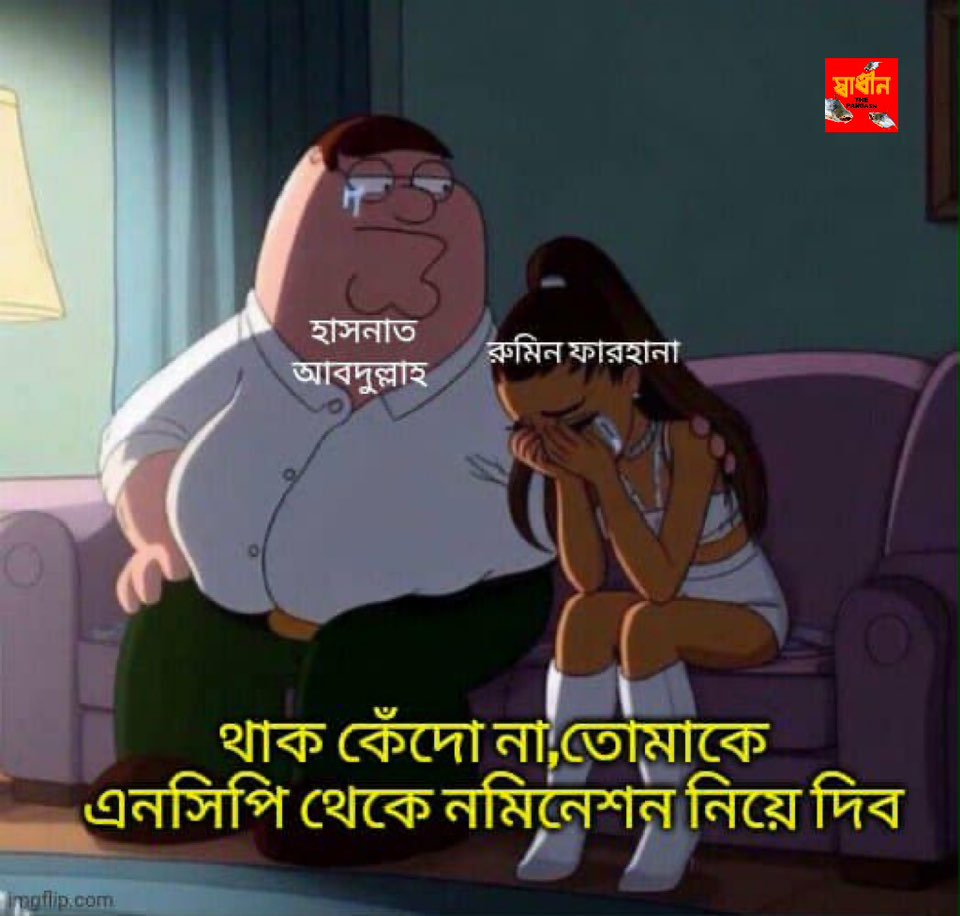

Generating classification...

Model Response:
--------------------------------------------------------------------------------
NonPolitical
--------------------------------------------------------------------------------

✅ Extracted Classification: NonPolitical


In [ ]:
# from PIL import Image
# from vllm import SamplingParams

# # Load test data
# test_df = pd.read_csv("Test.csv")

# # Get image folder path
# with open('image_folder_path.txt', 'r') as f:
#     image_folder = f.read().strip()

# print(f"Using image folder: {image_folder}\n")

# # Test on first image
# test_image_name = test_df.iloc[145]['Image_name']
# test_image_path = os.path.join(image_folder, test_image_name)
# test_image = Image.open(test_image_path).convert('RGB')
# test_image = test_image.resize((512, 512))

# print(f"Testing on: {test_image_name}")
# print(f"Testing on: {test_image_name}\n")

# # Display the image
# from IPython.display import display
# display(test_image)

# # Create prompt
# test_prompt_conv = create_classification_prompt()
# test_prompt_formatted = tokenizer.apply_chat_template(
#     test_prompt_conv,
#     tokenize=False,
#     add_generation_prompt=True
# )

# # Sampling parameters - adjusted for better balance
# sampling_params = SamplingParams(
#     temperature=0.1,  # Lower temperature for more deterministic output
#     top_k=20,         # Reduced for more focused predictions
#     top_p=0.85,       # Slightly reduced
#     max_tokens=50,    # Shorter responses to get cleaner answers
# )

# print("Generating classification...\n")

# # Generate using fast_generate
# outputs = model.fast_generate(
#     {
#         "prompt": test_prompt_formatted,
#         "multi_modal_data": {"image": test_image}
#     },
#     sampling_params,
# )

# response = outputs[0].outputs[0].text
# classification = extract_classification(response)

# print("Model Response:")
# print("-" * 80)
# print(response)
# print("-" * 80)
# print(f"\n✅ Extracted Classification: {classification}")
# print(f"\n✅ Classification Result: {classification}")

from PIL import Image
from qwen_vl_utils import process_vision_info

# Load test data
test_df = pd.read_csv("Test.csv")

# Get image folder path
with open('image_folder_path.txt', 'r') as f:
    image_folder = f.read().strip()

print(f"Using image folder: {image_folder}\n")

# Test on first image
test_image_name = test_df.iloc[145]['Image_name']
test_image_path = os.path.join(image_folder, test_image_name)
test_image = Image.open(test_image_path).convert('RGB')

print(f"Testing on: {test_image_name}\n")

# Display the image
from IPython.display import display
display(test_image)

# Create prompt with image embedded
test_prompt_conv = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": test_image},
            {"type": "text", "text": """You are an expert in analyzing Bengali and English memes, particularly those related to Bangladeshi and international politics. Your task is to classify this meme as either "Political" or "NonPolitical".

⚠️ **CRITICAL: If you see ANY of these Bengali words, IMMEDIATELY classify as Political:**
• এনসিপি (NCP political party)
• আওয়ামী লীগ (Awami League)
• বিএনপি (BNP)
• জামায়াত (Jamaat)
• জাতীয় পার্টি (Jatiya Party)
• সরকার (government)
• মনোনয়ন (nomination)
• নির্বাচন (election)
• দল (party)
• রাজনীতি (politics)

🔴 **POLITICAL** - Classify as Political if the meme contains ANY of these:

**Bangladeshi Political Parties:**
• এনসিপি or NCP or জাতীয় নাগরিক পার্টি (National Citizen Party)
• আওয়ামী লীগ or Awami League or বাংলাদেশ আওয়ামী লীগ
• বিএনপি or BNP or বাংলাদেশ জাতীয়তাবাদী দল (Bangladesh Nationalist Party)
• জাতীয় পার্টি or Jatiya Party
• জামায়াত or Jamaat or বাংলাদেশ জামায়াতে ইসলামী
• ANY other political party name

**Political Leaders (ANY mention = Political):**
• Sheikh Hasina, Khaleda Zia, Tarique Rahman, Ershad
• ANY current or former political leaders, MPs, ministers
• Political activists, party leaders, political candidates

**Political Context (ANY mention = Political):**
• মনোনয়ন (nomination) or নির্বাচন (election) or ভোট (vote)
• Political rallies, protests, হরতাল (hartal), political violence
• Parliament (জাতীয় সংসদ), cabinet, government offices
• Political speeches, quotes, or slogans
• Electoral symbols, party flags, party colors

**International Politics:**
• World leaders: Trump, Biden, Putin, Modi, Xi Jinping, etc.
• International political parties, wars, elections

🟢 **NONPOLITICAL** - Only classify as NonPolitical if:
• NO political party names (এনসিপি, আওয়ামী লীগ, বিএনপি, etc.)
• NO politicians or political figures
• NO government/political keywords (সরকার, মনোনয়ন, নির্বাচন, etc.)
• About: everyday life, relationships, entertainment, sports, education, culture
• Classify as NonPolitical if meaning of text present is non political even if political figures are shown

**Examples:**

✅ POLITICAL (Classify as Political):
- Text contains "এনসিপি" → Political
- Text contains "আওয়ামী লীগ" → Political
- Text contains "বিএনপি" → Political
- Text: "যখন সরকার বলে..." → Political
- Text: "এনসিপি মনোনয়ন দিয়েছে" → Political
- Shows any politician's face → Political
- Mentions any political party → Political

❌ NONPOLITICAL (Only if no political elements):
- Text: "যখন মা বলে..." (When mom says...) → NonPolitical
- Meme about SSC/HSC exams → NonPolitical
- Meme about Dhaka traffic (no government mention) → NonPolitical
- Meme about Shakib Al Hasan cricket → NonPolitical
- Meme about relationships → NonPolitical

**DECISION RULE:**
1. Read ALL text in the image (Bengali AND English)
2. If you find ANY political party name (especially এনসিপি, আওয়ামী লীগ, বিএনপি) → Political
3. If you see any politician's face → Political
4. If you see political keywords (সরকার, মনোনয়ন, নির্বাচন) → Political
5. If NONE of the above → NonPolitical

**OUTPUT**: Respond with EXACTLY ONE WORD - either "Political" or "NonPolitical" - nothing else."""}
        ]
    }
]

print("Generating classification...\n")

# Use standard HuggingFace generate (vLLM disabled)
text = tokenizer.apply_chat_template(
    test_prompt_conv, tokenize=False, add_generation_prompt=True
)
image_inputs, video_inputs = process_vision_info(test_prompt_conv)

inputs = tokenizer(
    text=[text],
    images=image_inputs,
    videos=video_inputs,
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to("cuda")

# Generate
generated_ids = model.generate(**inputs, max_new_tokens=50, temperature=0.1)
generated_ids_trimmed = [
    out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]
response = tokenizer.batch_decode(
    generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
)[0]

classification = extract_classification(response)

print("Model Response:")
print("-" * 80)
print(response)
print("-" * 80)
print(f"\n✅ Extracted Classification: {classification}")

### Run Inference on All Images

Process all test images and collect predictions.

In [ ]:
# from tqdm.auto import tqdm

# print(f"Processing {len(test_df)} images from folder: {image_folder}\n")

# # Sampling parameters - adjusted for better balance
# sampling_params = SamplingParams(
#     temperature=0.1,  # Lower temperature for more deterministic output
#     top_k=20,         # Reduced for more focused predictions
#     top_p=0.85,       # Slightly reduced
#     max_tokens=50,    # Shorter responses to get cleaner answers
# )

# predictions = []

# for idx, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Classifying"):
#     image_name = row['Image_name']
#     image_path = os.path.join(image_folder, image_name)

#     if not os.path.exists(image_path):
#         print(f"⚠️ Image not found: {image_path}")
#         predictions.append({
#             'Name': image_name,
#             'Image_name': image_name,
#             'Label': 'NonPolitical'
#         })
#         continue

#     try:
#         # Load and preprocess image
#         image = Image.open(image_path).convert('RGB')
#         image = image.resize((512, 512))

#         # Create prompt
#         prompt_conv = create_classification_prompt()
#         prompt_formatted = tokenizer.apply_chat_template(
#             prompt_conv,
#             tokenize=False,
#             add_generation_prompt=True
#         )

#         # Generate classification
#         outputs = model.fast_generate(
#             {
#                 "prompt": prompt_formatted,
#                 "multi_modal_data": {"image": image}
#             },
#             sampling_params,
#         )

#         response = outputs[0].outputs[0].text
#         classification = extract_classification(response)

#         predictions.append({
#             'Image_name': image_name,
#             'Label': classification
#         })
#     except Exception as e:
#         print(f"❌ Error processing {image_name}: {str(e)}")
#         predictions.append({
#             'Image_name': image_name,
#             'Label': 'NonPolitical'
#         })

# # Create results dataframe
# results_df = pd.DataFrame(predictions)
# # Create results dataframe
# print("\n" + "="*80)
# print("✅ INFERENCE COMPLETE!")
# print("="*80)
# # Save results to Test.csv
# results_df.to_csv('Test.csv', index=False)

# print("\n" + "="*80)
# print("✅ INFERENCE COMPLETE!")
# print(f"\n✅ Results saved to Test.csv with Label column")
# print(f"\n📊 Classification Distribution:")

# print(f"\nFirst 10 predictions:")# Show distribution

# print(results_df.head(10))

# print(f"\nLast 10 predictions:")
# print(results_df.tail(10))

from tqdm import tqdm
from qwen_vl_utils import process_vision_info

# Create predictions list
predictions = []

# Get image folder path
with open('image_folder_path.txt', 'r') as f:
    image_folder = f.read().strip()

print(f"Starting inference on {len(test_df)} images...")
print("Using standard HuggingFace inference\n")

# Process each image
for idx, row in tqdm(test_df.iterrows(), total=len(test_df)):
    try:
        image_name = row['Image_name']
        image_path = os.path.join(image_folder, image_name)

        # Load and convert image
        image = Image.open(image_path).convert('RGB')

        # Create prompt with image embedded
        prompt_conv = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {"type": "text", "text": """You are an expert in analyzing Bengali and English memes, particularly those related to Bangladeshi and international politics. Your task is to classify this meme as either "Political" or "NonPolitical".

⚠️ **CRITICAL: If you see ANY of these Bengali words, IMMEDIATELY classify as Political:**
• এনসিপি (NCP political party)
• আওয়ামী লীগ (Awami League)
• বিএনপি (BNP)
• জামায়াত (Jamaat)
• জাতীয় পার্টি (Jatiya Party)
• সরকার (government)
• মনোনয়ন (nomination)
• নির্বাচন (election)
• দল (party)
• রাজনীতি (politics)

🔴 **POLITICAL** - Classify as Political if the meme contains ANY of these:

**Bangladeshi Political Parties:**
• এনসিপি or NCP or জাতীয় নাগরিক পার্টি (National Citizen Party)
• আওয়ামী লীগ or Awami League or বাংলাদেশ আওয়ামী লীগ
• বিএনপি or BNP or বাংলাদেশ জাতীয়তাবাদী দল (Bangladesh Nationalist Party)
• জাতীয় পার্টি or Jatiya Party
• জামায়াত or Jamaat or বাংলাদেশ জামায়াতে ইসলামী
• ANY other political party name

**Political Leaders (ANY mention = Political):**
• Sheikh Hasina, Khaleda Zia, Tarique Rahman, Ershad
• ANY current or former political leaders, MPs, ministers
• Political activists, party leaders, political candidates

**Political Context (ANY mention = Political):**
• মনোনয়ন (nomination) or নির্বাচন (election) or ভোট (vote)
• Political rallies, protests, হরতাল (hartal), political violence
• Parliament (জাতীয় সংসদ), cabinet, government offices
• Political speeches, quotes, or slogans
• Electoral symbols, party flags, party colors

**International Politics:**
• World leaders: Trump, Biden, Putin, Modi, Xi Jinping, etc.
• International political parties, wars, elections

🟢 **NONPOLITICAL** - Only classify as NonPolitical if:
• NO political party names (এনসিপি, আওয়ামী লীগ, বিএনপি, etc.)
• NO politicians or political figures
• NO government/political keywords (সরকার, মনোনয়ন, নির্বাচন, etc.)
• About: everyday life, relationships, entertainment, sports, education, culture
• Classify as NonPolitical if meaning of text present is non political even if political figures are shown

**Examples:**

✅ POLITICAL (Classify as Political):
- Text contains "এনসিপি" → Political
- Text contains "আওয়ামী লীগ" → Political
- Text contains "বিএনপি" → Political
- Text: "যখন সরকার বলে..." → Political
- Text: "এনসিপি মনোনয়ন দিয়েছে" → Political
- Shows any politician's face → Political
- Mentions any political party → Political

❌ NONPOLITICAL (Only if no political elements):
- Text: "যখন মা বলে..." (When mom says...) → NonPolitical
- Meme about SSC/HSC exams → NonPolitical
- Meme about Dhaka traffic (no government mention) → NonPolitical
- Meme about Shakib Al Hasan cricket → NonPolitical
- Meme about relationships → NonPolitical

**DECISION RULE:**
1. Read ALL text in the image (Bengali AND English)
2. If you find ANY political party name (especially এনসিপি, আওয়ামী লীগ, বিএনপি) → Political
3. If you see any politician's face → Political
4. If you see political keywords (সরকার, মনোনয়ন, নির্বাচন) → Political
5. If NONE of the above → NonPolitical

**OUTPUT**: Respond with EXACTLY ONE WORD - either "Political" or "NonPolitical" - nothing else."""}
                ]
            }
        ]

        # Standard HuggingFace inference
        text = tokenizer.apply_chat_template(
            prompt_conv, tokenize=False, add_generation_prompt=True
        )
        image_inputs, video_inputs = process_vision_info(prompt_conv)

        inputs = tokenizer(
            text=[text],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt",
        )
        inputs = inputs.to("cuda")

        generated_ids = model.generate(**inputs, max_new_tokens=50, temperature=0.1)
        generated_ids_trimmed = [
            out_ids[len(in_ids):] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
        ]
        response = tokenizer.batch_decode(
            generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
        )[0]

        # Extract classification
        classification = extract_classification(response)

        predictions.append({
            'Image_name': image_name,
            'Prediction': classification
        })

    except Exception as e:
        print(f"\n❌ Error processing {image_name}: {str(e)}")
        predictions.append({
            'Image_name': image_name,
            'Prediction': 'NonPolitical'  # Default fallback
        })

# Create submission DataFrame
submission_df = pd.DataFrame(predictions)

print(f"\n✅ Completed inference on {len(predictions)} images")
print(f"\nClass Distribution in Predictions:")
print(submission_df['Prediction'].value_counts())
print(f"\nPercentages:")
print(submission_df['Prediction'].value_counts(normalize=True) * 100)

Starting inference on 330 images...
Using standard HuggingFace inference



100%|██████████| 330/330 [29:10<00:00,  5.31s/it]


✅ Completed inference on 330 images

Class Distribution in Predictions:
Prediction
Political       171
NonPolitical    159
Name: count, dtype: int64

Percentages:
Prediction
Political       51.818182
NonPolitical    48.181818
Name: proportion, dtype: float64


In [ ]:
submission_df.head()

submission_df = submission_df.rename(columns={"Prediction": "Label"})

submission_df.head()

submission_df.to_csv("updated_file.csv", index=False)


In [ ]:
print(f"\nClass Distribution in Predictions:")
print(submission_df['Label'].value_counts())
print(f"\nPercentages:")
print(submission_df['Label'].value_counts(normalize=True) * 100)


Class Distribution in Predictions:
Label
Political       171
NonPolitical    159
Name: count, dtype: int64

Percentages:
Label
Political       51.818182
NonPolitical    48.181818
Name: proportion, dtype: float64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Results Summary

View classification statistics and download results.

In [ ]:
# Display predicted label distribution
print("\n" + "="*80)
print("📊 PREDICTED LABEL DISTRIBUTION")
print("="*80)

print("\n📈 Predicted Labels:")
label_counts = results_df['Label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(results_df)) * 100
    print(f"  {label:<15}: {count:>4} images ({percentage:>5.1f}%)")

print(f"\n📝 Total images classified: {len(results_df)}")

# Check if ground truth exists for evaluation
if os.path.exists("predictions01.csv"):
    print("\n" + "="*80)
    print("📊 EVALUATION WITH GROUND TRUTH")
    print("="*80)

    # Load ground truth
    gt_df = pd.read_csv("predictions01.csv")

    # Show ground truth distribution
    print("\n📈 Ground Truth Label Distribution:")
    gt_label_col = 'Label' if 'Label' in gt_df.columns else 'label'
    gt_image_col = 'Image_name' if 'Image_name' in gt_df.columns else 'image_name'

    gt_label_counts = gt_df[gt_label_col].value_counts()
    for label, count in gt_label_counts.items():
        percentage = (count / len(gt_df)) * 100
        print(f"  {label:<15}: {count:>4} images ({percentage:>5.1f}%)")

    # Merge predictions with ground truth - handle different column names
    # Rename ground truth columns before merging
    gt_df_renamed = gt_df.copy()
    gt_df_renamed = gt_df_renamed.rename(columns={
        gt_image_col: 'Image_name_GT',
        gt_label_col: 'Ground_Truth'
    })

    merged_df = results_df.merge(
        gt_df_renamed[['Image_name_GT', 'Ground_Truth']],
        left_on='Image_name',
        right_on='Image_name_GT',
        how='inner'
    )

    print(f"\n✅ Matched {len(merged_df)} images for evaluation")

    # Calculate metrics
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
    import numpy as np

    y_true = merged_df['Ground_Truth'].values
    y_pred = merged_df['Label'].values

    # Overall accuracy
    accuracy = accuracy_score(y_true, y_pred)

    # Per-class metrics
    categories = ['Political', 'NonPolitical']
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=categories, average=None, zero_division=0
    )

    # Macro averages
    macro_precision = np.mean(precision)
    macro_recall = np.mean(recall)
    macro_f1 = np.mean(f1)

    print("\n" + "="*80)
    print("📊 CLASSIFICATION METRICS")
    print("="*80)
    print(f"\n🎯 Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print("\n" + "-" * 80)
    print(f"{'Category':<15} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support':<10}")
    print("-" * 80)
    for i, cat in enumerate(categories):
        print(f"{cat:<15} {precision[i]:<12.4f} {recall[i]:<12.4f} {f1[i]:<12.4f} {support[i]:<10}")
    print("-" * 80)
    print(f"{'Macro Avg':<15} {macro_precision:<12.4f} {macro_recall:<12.4f} {macro_f1:<12.4f} {len(y_true):<10}")
    print("-" * 80)

    # Confusion Matrix
    print("\n" + "="*80)
    print("🔢 CONFUSION MATRIX")
    print("="*80)
    cm = confusion_matrix(y_true, y_pred, labels=categories)
    cm_df = pd.DataFrame(cm, index=categories, columns=categories)
    print("\n" + str(cm_df))

    # Detailed classification report
    print("\n" + "="*80)
    print("📋 DETAILED CLASSIFICATION REPORT")
    print("="*80)
    print("\n" + classification_report(y_true, y_pred, labels=categories, zero_division=0))

    # Show some correct and incorrect predictions
    merged_df['Correct'] = merged_df['Label'] == merged_df['Ground_Truth']
    correct_count = merged_df['Correct'].sum()
    incorrect_count = len(merged_df) - correct_count

    print("\n" + "="*80)
    print("📊 PREDICTION ACCURACY BREAKDOWN")
    print("="*80)
    print(f"\n✅ Correct predictions: {correct_count} ({correct_count/len(merged_df)*100:.1f}%)")
    print(f"❌ Incorrect predictions: {incorrect_count} ({incorrect_count/len(merged_df)*100:.1f}%)")

    # Show sample errors
    if incorrect_count > 0:
        print("\n" + "-" * 80)
        print("Sample Incorrect Predictions (first 10):")
        print("-" * 80)
        incorrect_df = merged_df[merged_df['Correct'] == False]
        print(incorrect_df[['Image_name', 'Label', 'Ground_Truth']].head(10).to_string(index=False))
else:
    print("\n⚠️ predictions01.csv not found - skipping evaluation metrics")
    print("   Upload predictions01.csv to see accuracy, F1 scores, and confusion matrix")

# Show sample predictions
print("\n" + "="*80)
print("📋 SAMPLE PREDICTIONS")
print("="*80)
print("\nFirst 20 predictions:")
print(results_df.head(20).to_string(index=False))

print("\n\nLast 20 predictions:")
print(results_df.tail(20).to_string(index=False))

# Download instructions
print("\n" + "="*80)
print("💾 DOWNLOAD RESULTS")
print("="*80)
print("\n✅ Results have been saved to: Test.csv")
print("\nTo download in Colab:")
print("1. Click the 📁 folder icon on the left")
print("2. Find 'Test.csv' in the file list")
print("3. Click the ⋮ (three dots) next to Test.csv")
print("4. Select 'Download'")

print("\n" + "="*80)


📊 PREDICTED LABEL DISTRIBUTION

📈 Predicted Labels:
  NonPolitical   :  230 images ( 69.7%)
  Political      :  100 images ( 30.3%)

📝 Total images classified: 330

📊 EVALUATION WITH GROUND TRUTH

📈 Ground Truth Label Distribution:
  NonPolitical   :  194 images ( 58.8%)
  Political      :  136 images ( 41.2%)

✅ Matched 330 images for evaluation

📊 CLASSIFICATION METRICS

🎯 Overall Accuracy: 0.8242 (82.42%)

--------------------------------------------------------------------------------
Category        Precision    Recall       F1-Score     Support   
--------------------------------------------------------------------------------
Political       0.8900       0.6544       0.7542       136       
NonPolitical    0.7957       0.9433       0.8632       194       
--------------------------------------------------------------------------------
Macro Avg       0.8428       0.7989       0.8087       330       
-------------------------------------------------------------------------------

### Download Results

Your classified results are ready to download!


In [ ]:
# Display final dataframe
print("📊 Final Results Preview:")
print("="*80)
print(results_df.to_string(index=False, max_rows=50))

# Provide download link for Colab
from google.colab import files
print("\n" + "="*80)
print("💾 Downloading Test.csv...")
print("="*80)
files.download('Test.csv')
print("\n✅ Download complete!")

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<REASONING>
To measure the length of the nail, we need to align it with the ruler and observe where it ends relative to the markings on the ruler.

1. Place the nail on the ruler so that the tip of the nail is at the 0-inch mark.
2. Observe where the back end of the nail falls on the ruler.
3. The back end of the nail appears to be just past the 3-inch mark but not quite reaching the 4-inch mark.

Since the question asks for the length to the nearest inch, we need to determine if the nail is closer to 3 inches or 4 inches in length. In this case, the nail is closer to 3 inches than to 4 inches because the back end of the nail is closer to the 3-inch mark than the 4-inch mark.

Therefore, the nail is about 3 inches long.
</REASONING>

<SOLUTION>
3</SOLUTION>


### Summary

Binary political meme classification complete! The notebook has:
1. ✅ Loaded the Qwen2.5-VL-7B-Instruct model
2. ✅ Processed all test images
3. ✅ Classified memes into Political/NonPolitical categories
4. ✅ Saved results with Label column to Test.csv
5. ✅ Downloaded results file

Your Test.csv file now contains the Image_name and Label columns ready for submission!

Unsloth: We now expect `per_device_train_batch_size` to be a multiple of `num_generations`.
We will change the batch size of 1 to the `num_generations` of 4


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 566 | Num Epochs = 1 | Total steps = 142
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 8,332,536,832 (0.48% trained)


-------------------- Question:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>What is the highest value on the X axis?. Also first provide your reasoning or working out on how you would go about solving the question between <REASONING> and </REASONING> and then your final answer between <SOLUTION> and (put a single float here) </SOLUTION><|im_end|>
<|im_start|>assistant
 
Answer:
30 
Response:<REASONING>
To determine the highest value on the X-axis, I need to look at the numerical markings on the horizontal axis, which represents the "MICROGRAMS/mL-E-DNP-LYSIME-HCL" on the figure.

The X-axis is labeled with numerical values from 0 to 30, with increments of 5. The highest value marked on the X-axis is 30.

</REASONING>

<SOLUTION>
30.0 </SOLUTION>
Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,kl,rewards / formatting_reward_func / mean,rewards / formatting_reward_func / std,rewards / correctness_reward_func / mean,rewards / correctness_reward_func / std
1,0.030200,1.750000,0.288675,182.750000,100.000000,302.000000,0.000000,182.750000,100.000000,302.000000,0.000012,1.750000,0.462910,0.000000,0.000000
2,-0.010900,1.750000,0.500000,188.625000,131.000000,268.000000,0.000000,188.625000,131.000000,268.000000,0.000000,1.750000,0.707107,0.000000,0.000000
3,0.000000,2.000000,0.000000,187.375000,133.000000,305.000000,0.000000,187.375000,133.000000,305.000000,0.000006,2.000000,0.000000,0.000000,0.000000
4,-0.017800,1.625000,0.478714,304.625000,129.000000,677.000000,0.000000,304.625000,129.000000,677.000000,0.000007,1.625000,0.744024,0.000000,0.000000
5,0.012800,1.750000,0.866025,272.875000,175.000000,342.000000,0.000000,272.875000,175.000000,342.000000,0.000009,1.500000,0.755929,0.250000,0.707107
6,0.085500,1.125000,0.767389,257.750000,162.000000,358.000000,0.000000,257.750000,162.000000,358.000000,0.000016,1.125000,0.834523,0.000000,0.000000
7,0.012400,1.625000,0.538675,160.625000,105.000000,196.000000,0.000000,160.625000,105.000000,196.000000,0.000009,1.625000,0.517549,0.000000,0.000000
8,-0.029900,2.125000,0.750000,140.625000,92.000000,274.000000,0.000000,140.625000,92.000000,274.000000,0.000007,1.875000,0.353553,0.250000,0.707107
9,-0.002300,1.875000,0.250000,224.500000,140.000000,344.000000,0.000000,224.500000,140.000000,344.000000,0.000008,1.875000,0.353553,0.000000,0.000000
10,0.038600,1.375000,0.250000,316.500000,139.000000,514.000000,0.000000,316.500000,139.000000,514.000000,0.000010,1.375000,0.744024,0.000000,0.000000


-------------------- Question:
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>如图，点A、B、C都在半径为2的⊙O上，∠C＝30°，则弦AB长为（）. Also first provide your reasoning or working out on how you would go about solving the question between <REASONING> and </REASONING> and then your final answer between <SOLUTION> and (put a single float here) </SOLUTION><|im_end|>
<|im_start|>assistant
 
Answer:
2 
Response:<REASONING>
To find the length of弦AB, we can use properties of circles and the angles subtended by the chord.

1. **Identify the angle subtended by the chord at the center**: The angle \(\angle AOB\) at the center O corresponds to the angle \(\angle ACB\) at the circumference. This is given by the Inscribed Angle Theorem, which states that the central angle is twice the inscribed angle that subtends the same arc. Therefore, if \(\angle ACB = 30^\circ\), then \(\angle AOB = 2 \times 30^\circ = 60^\circ\).

2. **Determine the triangle 

TrainOutput(global_step=142, training_loss=0.014322312211204839, metrics={'train_runtime': 23888.6719, 'train_samples_per_second': 0.012, 'train_steps_per_second': 0.006, 'total_flos': 0.0, 'train_loss': 0.014322312211204839})

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

To solve for the magnitude of the average force on the driver during the collision, we need to use the impulse-momentum theorem. The impulse-momentum theorem states that the impulse (force over time) is equal to the change in momentum.

Given:
- Initial velocity \( v_i = 70 \, \text{m/s} \) at \( 30^\circ \) from the wall.
- Final velocity \( v_f = 50 \, \text{m/s} \) at \( 10^\circ \) from the wall.
- Mass \( m = 80 \, \text{kg} \).
- Duration of the collision \( \Delta t = 14 \, \text{ms} = 14 \times 10^{-3} \, \text{s} \).

### Reasoning:

1. **Calculate the initial momentum \( \mathbf{p}_i \):**
   \[
   \mathbf{p}_i = m v_i \hat{\mathbf{v}}_i
   \]
   The initial velocity \( \mathbf{v}_i \) can be broken into components:
   \[
   v_{ix} = v_i \cos(30^\circ)
   \]
   \[
   v_{iy} = v_i \sin(30^\circ)
   \]
   Using \( \cos(30^\circ) = \frac{\sqrt{3}}{2} \) and \( \sin(30^\circ) = \frac{1}{2} \):
   \[
   v_{ix} = 70 \times \frac{\sqrt{3}}{2} = 70 \times 0.866 = 60.62 \, \text{m/s}


### Done!

🎉 **Meme Classification Complete!**

Your results are saved in `predictions_with_groundtruth.csv`

For more Unsloth notebooks and documentation:
- [Documentation](https://docs.unsloth.ai/)
- [Discord](https://discord.gg/unsloth)
- [GitHub](https://github.com/unslothai/unsloth)

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
</div>
